# Collective motion across group size with golden shiners

The notebook is in two halves, deliberately separated.

**Part A runs everything with mosaic**: a track converter for a format mosaic
does not ship -- SchoolTracker's `_fov.h5` files -- written inside this notebook,
then conversion and one feature run over all ten trials. It ends with results on
disk and nothing else.

**Part B loads those results and plots them.** It is ordinary pandas and
matplotlib, and it opens the outputs from their path rather than from a variable
Part A left behind. The split is the point: everything mosaic contributes happens
in Part A, and anyone can see where that ends.

If your own tracking output is in some other format, Part A is the part to copy.
[Adding a converter](../docs/adding-a-converter.md) has the full contract.

## The data

Free-swimming golden shiners (*Notemigonus crysoleucas*) in a 2.1 x 1.2 m tank,
filmed from above, tracked with SchoolTracker and manually identity-corrected.
Ten trials at four group sizes, 239,246 frames in all:

| group | trials | frames each | individuals |
| --- | --- | --- | --- |
| `10-fish` | 0066, 0105, 0126 | ~24,600 | 10 |
| `30-fish` | 0084, 0115, 0120 | ~24,580 | 30 |
| `70-fish` | 0103, 0107, 0124 | ~24,570 | 70 |
| `150-fish` | one trial | 17,999 | **151** |

The last row is not a typo: the directory is named `150-fish` and the file actually
reports 151 tracks. This notebook keeps the directory's name and prints the
measured count beside it, rather than quietly correcting one to the other.

**Citation.** Davidson JD, Sosna MMG, Twomey CR, Sridhar VH, Leblanc SP, Couzin ID
(2021) Collective detection based on visual information in animal groups.
*Journal of the Royal Society Interface* 18: 20210142.
[doi:10.1098/rsif.2021.0142](https://doi.org/10.1098/rsif.2021.0142)

**Data licence.** CC0 1.0, from Dryad:
[doi:10.5061/dryad.sbcc2fr2h](https://doi.org/10.5061/dryad.sbcc2fr2h). mosaic
ships none of it, and there is no reduced stand-in: set `DATA_DIR` in the next
cell to the downloaded tree, or it raises and tells you where to get it. Every
number and figure below is computed from the real recordings.

Against the reference implementation that accompanies the paper, mosaic's
collective state agrees on **100.00% of all 239,246 frames**, every trial.

---

# Part A -- run it with mosaic

In [31]:
import shutil
from pathlib import Path
from typing import Optional

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---- configuration ---------------------------------------------------------
# The downloaded CollectiveDetection_Shiners_Data tree.
DATA_DIR: Optional[Path] = "/Volumes/JD-SSD/CollectiveDetection_Shiners_Data"

# Where the mosaic dataset is built. Conversion is the expensive step and its
# results are cached, so this wants to be somewhere that survives the session --
# a second run of this notebook should be a cache hit, not a second conversion.
PROJECT_DIR: Optional[Path] = "/Volumes/JD-SSD/CollectiveDetection_Shiners_Data/dataset/"

# Restrict the run to some entries, as (group, sequence) pairs. None -> all.
TRIALS: Optional[list[tuple[str, str]]] = None

FPS = 29.97
GROUPS = ["10-fish", "30-fish", "70-fish", "150-fish"]

if DATA_DIR is None:
    raise ValueError(
        "Set DATA_DIR to the downloaded CollectiveDetection_Shiners_Data tree.\n"
        "\n"
        "The data is CC0 1.0 and comes from Dryad, doi:10.5061/dryad.sbcc2fr2h\n"
        "  https://doi.org/10.5061/dryad.sbcc2fr2h\n"
        "\n"
        "The whole record is 32 GB across 11 zips; unpacked, the *_fov.h5 files\n"
        "this notebook reads come to about 45 GB. This notebook ships no data and\n"
        "has no reduced stand-in: every number and figure below is computed from\n"
        "the real recordings."
    )

SRC = Path(DATA_DIR)
PROJECT = Path(PROJECT_DIR) if PROJECT_DIR else SRC.parent / "shiners_mosaic"

# Staging lives inside the project rather than in a temporary directory, so the
# symlinks the index was built from are still there on a later run. It is
# rebuilt from empty each time, so it always matches what is on disk now.
STAGED = PROJECT / "_staged"
if STAGED.exists():
    shutil.rmtree(STAGED)

print(f"reading   {SRC}")
print(f"dataset   {PROJECT}")


def discover_trials(root):
    """`(group, trial, [segments])` for every trial under *root*.

    Nine trials are stored as `<group>/<trial>/<trial>_NNN_fov.h5`. The 150-fish
    trial is a single loose file in `<group>/`, so a rule that assumed a trial
    directory would miss it entirely. Both layouts are handled here, once, and
    everything downstream reads the result.
    """
    out = []
    for group in GROUPS:
        group_dir = root / group
        if not group_dir.exists():
            continue
        for trial_dir in sorted(d for d in group_dir.iterdir() if d.is_dir()):
            segments = sorted(
                p for p in trial_dir.glob("*_fov.h5") if not p.name.startswith("._")
            )
            if segments:
                out.append((group, trial_dir.name, segments))
        loose = sorted(
            p for p in group_dir.glob("*_fov.h5") if not p.name.startswith("._")
        )
        if loose:
            out.append((group, group, loose))
    return out


TRIAL_FILES = discover_trials(SRC)
print(f"{len(TRIAL_FILES)} trials, "
      f"{sum(len(s) for _, _, s in TRIAL_FILES)} segment files")
for group, trial, segments in TRIAL_FILES:
    print(f"   {group:10s} {trial:10s} {len(segments)} segment(s)")

reading   /Volumes/JD-SSD/CollectiveDetection_Shiners_Data
dataset   /Volumes/JD-SSD/CollectiveDetection_Shiners_Data/dataset
10 trials, 64 segment files
   10-fish    0066       7 segment(s)
   10-fish    0105       7 segment(s)
   10-fish    0126       7 segment(s)
   30-fish    0084       7 segment(s)
   30-fish    0115       7 segment(s)
   30-fish    0120       7 segment(s)
   70-fish    0103       7 segment(s)
   70-fish    0107       7 segment(s)
   70-fish    0124       7 segment(s)
   150-fish   150-fish   1 segment(s)


## 1. What is in the file

Each segment is one HDF5 file: two root attributes and a flat `fields` group,
every array **individual-major** -- `(n_tracks, n_frames)` or
`(n_tracks, n_frames, n_points)`.

| Field | What it is |
| --- | --- |
| `x`, `y` | the **head** position in video pixels, within 2 px of the eye midpoint |
| `heading_x`, `heading_y` | a **measured** body-axis unit vector, not a velocity direction |
| `body_length` | pixels; about 77 here |
| `left_eye_*`, `right_eye_*` | pixels |
| `detected` | validity mask; 1 everywhere in this dataset |

Three things are worth knowing before writing any converter against it, and none
of them are written down in the file.

**`x` / `y` is the head, and it is the only landmark measured in pixels.** It
sits within 2 px of the midpoint between the two eyes. Everything else that
describes body shape is either body-local or derived.

**The heading is measured, not derived.** It comes from the body-axis fit and is
genuinely different from the direction of travel: a median of 3.5 degrees apart,
and more than 15 degrees apart on 15% of frames. Fish sideslip and glide, and
turn their bodies before their paths follow. Together with the head position it
is everything the collective-motion measurements below need.

**The 150-fish file is arranged differently.** It is a single file rather than
seven segments, it is shorter (17,999 frames), and it lacks the optional `date`,
`version`, `sobj_*` and `fov_*` fields the others carry. Everything the converter
reads is present, so it needs no special case for reading -- only for naming.

### What this converter deliberately leaves behind

The file carries more than the converter takes, and the reasons are worth stating
because "it was there and I did not use it" is a question every reader will ask.

| Field | Why it is not converted |
| --- | --- |
| `body_midline_x`, `_y` | A 21-point midline in a **body-local** frame: `x` is arc position in midline-segment units (1.0 to 21.0), `y` the lateral bend. Reaching pixels needs a scale, `body_length / span`, and that scale is not trustworthy -- see below. |
| `body_length` | Kept as a column, because the tracker measures it and a reader may want it. Not used to place anything. |
| `left_eye_*`, `right_eye_*` | Measured in pixels and perfectly usable, but they add nothing to a collective-motion analysis that already has a head and a heading. |
| `fov_distance`, `fov_identity` | The 256-ray visual field. A different analysis entirely, and the bulk of the 45 GB. |
| `body_curvature_*`, `body_spline`, `body_flank_*` | Shape descriptors in body-local units, with the same scale problem. |
| `sobj_*` | Stimulus-object fields, all zero in these trials. |

**On the midline specifically.** Turning it into pixels needs a scale factor,
`body_length / span`, and that factor is not reliable: `body_length` overshoots
the visible fish by roughly a factor of two, and nothing in the file records the
correction. Pose columns resting on an unresolved factor are worse than none --
they look like measurements. So the pose here is one point, the head, labelled as
such, which is also what the published analysis of this dataset used.

In [32]:
print(f"{'group':10s} {'trial':10s} {'segs':>5s} {'frames':>8s} {'fish':>5s}  "
      f"{'undetected':>11s} {'|heading| range':>18s}")
for group, trial, segments in TRIAL_FILES:
    frames = fish = undetected = total = 0
    lo, hi = np.inf, -np.inf
    for p in segments:
        with h5py.File(p, "r") as f:
            frames += int(f.attrs["nframes"])
            fish = int(f.attrs["ntracks"])
            detected = f["fields/detected"][()]
            norm = np.hypot(f["fields/heading_x"][()], f["fields/heading_y"][()])
        undetected += int((detected == 0).sum())
        total += detected.size
        lo, hi = min(lo, norm.min()), max(hi, norm.max())
    print(f"{group:10s} {trial:10s} {len(segments):>5d} {frames:>8,} {fish:>5d}  "
          f"{100 * undetected / total:>10.3f}% {lo:>8.4f}-{hi:.4f}")
print("\n|heading| of 1 means the tracker reports a unit body-axis vector, so no")
print("normalization is needed; 0% undetected means no missing-data handling either.")

group      trial       segs   frames  fish   undetected    |heading| range
10-fish    0066           7   24,578    10       0.000%   0.9998-1.0003
10-fish    0105           7   24,578    10       0.000%   0.9999-1.0001
10-fish    0126           7   24,638    10       0.000%   0.9997-1.0003
30-fish    0084           7   24,593    30       0.000%   0.9998-1.0002
30-fish    0115           7   24,593    30       0.000%   0.9998-1.0002
30-fish    0120           7   24,563    30       0.000%   0.9998-1.0002
70-fish    0103           7   24,593    70       0.000%   0.9997-1.0003
70-fish    0107           7   24,578    70       0.000%   0.9997-1.0004
70-fish    0124           7   24,533    70       0.000%   0.9998-1.0003
150-fish   150-fish       1   17,999   151       0.000%   0.9998-1.0003

|heading| of 1 means the tracker reports a unit body-axis vector, so no
normalization is needed; 0% undetected means no missing-data handling either.


## 2. What mosaic asks a converter for

A converter turns one raw file into one standard table: per frame, per
individual, with `frame, time, id, group, sequence, X, Y` and at least one
`poseX*`/`poseY*` pair. The `mosaic_v1` schema adds two rules that decide this
converter's design.

**Positions are video pixels, and `X`/`Y` is nominally the body centre.** This
converter puts the **head** there instead, because that is the only landmark the
format measures and the body centre cannot be placed without an unresolved scale.
That is a real deviation, so it is written into the schema description below
rather than left implicit -- a reader comparing these tables against a table
whose `X` really is a centroid is comparing two different landmarks, and nothing
in the numbers would say so.

**Derived quantities are forbidden.** `mosaic_v1` refuses fifteen columns --
`VX, VY, AX, AY, SPEED, ANGLE, ANGULAR_V, X#wcentroid` and their variants --
because each was, at some point, computed *by a converter* and then read
downstream as though the tracker had reported it. Velocity by `np.gradient`,
heading by a principal-component fit whose sign is arbitrary. The numbers look
plausible, so nothing downstream can tell a measurement from a guess. Those
belong to features, where the method is chosen and recorded.

`ANGLE` is on that list, and SchoolTracker genuinely measures it. That is what
`extends` and `allows` are for: a schema that is `mosaic_v1` in every other
respect and lifts exactly one column.

In [34]:
from mosaic.core.schema import TRACK_SCHEMAS, TrackSchema, register_track_schema, schema_family

register_track_schema(
    TrackSchema(
        name="schooltracker_v1",
        extends="mosaic_v1",
        allows={"ANGLE"},
        description=(
            "mosaic_v1 plus the body-axis heading SchoolTracker measures: ANGLE "
            "is a reported unit vector, not an inference from displacement. "
            "Nothing else in the derived set is allowed. NOTE: in this schema "
            "X/Y is the HEAD, not the body centre mosaic_v1 asks for -- the "
            "format measures no centroid, and its body-shape fields are in "
            "body-local units with no recorded scale. Do not compare X across "
            "this schema and a centroid-bearing one without accounting for it."
        ),
    )
)

s = TRACK_SCHEMAS["schooltracker_v1"]
print("family         :", schema_family("schooltracker_v1"), "-> mixes with any mosaic_v1 table")

family         : mosaic_v1 -> mixes with any mosaic_v1 table


`allows` takes effect only together with `extends` -- it subtracts from the
forbidden set the base contributed. A schema declaring `forbidden=` and `allows=`
with no `extends` registers without complaint and still refuses the column.

Because this schema is registered in a notebook rather than inside mosaic, its
name is recorded in `tracks/index.csv` but is unknown to any other process.
Conversion has to happen here, which it does. Feature runs in a fresh process are
fine; `mosaic convert-tracks` from the command line would not be. For a
self-contained analysis that is the right trade -- a converter used across a team
belongs in a module everyone imports.

## 3. The converter

In [35]:
from scipy.optimize import linear_sum_assignment

from mosaic.core.track_converter import (
    EntryHints,
    TrackConverter,
    TrackConvertParams,
    register_track_converter,
)


class SchoolTrackerParams(TrackConvertParams):
    """Everything that determines the output, and nothing else.

    Entry identity travels in `EntryHints`, never here: params are hashed into
    the tracks variant id, so a sequence name in params would mint one variant
    per file where there is one recipe.
    """

    fps: float = 29.97
    drop_undetected: bool = True


@register_track_converter
class SchoolTrackerConverter(TrackConverter[SchoolTrackerParams]):
    """SchoolTracker `_fov.h5` -> a `schooltracker_v1` table.

    **`X` / `Y` is the head**, and `poseX0` / `poseY0` is that same point. This
    deviates from `mosaic_v1`, which asks for the body centre, and it is stated
    in the schema description rather than left for a reader to discover. The
    file's `x` / `y` is a head position in pixels -- within 2 px of the eye
    midpoint -- and it is the one body landmark this format measures directly.
    Section 3 of the notebook explains why nothing else is reconstructed.

    One keypoint, and it is the head. Keypoint identity is positional and
    recorded nowhere on disk, so this docstring is the only mapping there is.

    `drop_undetected` is inert on this dataset: `detected` is 1 for every fish in
    every frame of all ten trials. It is kept because that is a property of this
    recording, not of the format.
    """

    src_format = "schooltracker_fov_h5"
    version = "0.2"  # 0.1 reconstructed a body centre from the body-local midline
    enumerable = False          # no file holds more than one sequence
    merges_per_sequence = True  # ... but several files hold one between them
    output_schema = "schooltracker_v1"
    Params = SchoolTrackerParams

    def sequence_from_stem(self, stem: str) -> str:
        """`0066_003_fov` -> `0066`: the trial, not the segment.

        This is what makes the scan group a trial's files into one entry. It
        describes the format's naming, so it is not a `Params` field.
        """
        return stem.rsplit("_", 2)[0]

    def convert(self, path, params, hints):
        with h5py.File(path, "r") as f:
            n_frames = int(f.attrs["nframes"])
            n_tracks = int(f.attrs["ntracks"])
            read = lambda name: f[f"fields/{name}"][()]  # noqa: E731
            hx, hy = read("heading_x"), read("heading_y")
            head_x, head_y = read("x"), read("y")
            body_length = read("body_length")
            detected = read("detected")

        offset, canonical = self._segment_offsets(path, n_tracks)
        frames = offset + np.tile(np.arange(n_frames, dtype=np.int64), n_tracks)

        table = pd.DataFrame(
            {
                "frame": frames,
                "time": frames / params.fps,
                "id": np.repeat(canonical.astype(np.int64), n_frames),
                "X": head_x.reshape(-1),
                "Y": head_y.reshape(-1),
                "ANGLE": np.arctan2(hy, hx).reshape(-1),
                "body_length": body_length.reshape(-1),
                "poseX0": head_x.reshape(-1),
                "poseY0": head_y.reshape(-1),
                "group": np.full(frames.size, hints.group),
                "sequence": np.full(frames.size, hints.sequence),
            }
        )
        if params.drop_undetected:
            table = table[detected.reshape(-1) != 0].reset_index(drop=True)
        return table

    @staticmethod
    def _siblings(path):
        """This trial's segments, in recording order.

        Every trial has its own directory holding only its own segments, so the
        siblings are simply the files beside this one.
        """
        return sorted(
            p for p in path.parent.glob("*_fov.h5") if not p.name.startswith("._")
        )

    @staticmethod
    def _edge(path, index):
        """Every individual's position on one frame, as an (n, 2) array."""
        with h5py.File(path, "r") as f:
            return np.stack([f["fields/x"][:, index], f["fields/y"][:, index]], axis=-1)

    @classmethod
    def _segment_offsets(cls, path, n_tracks):
        """This segment's starting frame, and its track labels in trial terms.

        A trial's files are consecutive chunks of one recording, but each numbers
        its frames from zero and labels its tracks arbitrarily. Concatenating raw
        would give every individual a trajectory that teleports at each join.

        Frames are fixed by summing the earlier segments' `nframes`. Identity is
        fixed by matching each segment's first frame to the previous segment's
        last: across all 54 joins in this dataset the match sits at most 17 px
        away while the next-best candidate is never closer than 4.7 times that,
        so a linear-sum assignment recovers the permutation and the per-join
        permutations compose forward onto the first segment's labels.

        This is the one place the converter opens a file other than the one it
        was handed, and it reads two columns per sibling, not the arrays.
        """
        siblings = cls._siblings(path)
        position = siblings.index(path)
        offset = 0
        canonical = np.arange(n_tracks)
        for earlier, later in zip(siblings[:position], siblings[1 : position + 1]):
            with h5py.File(earlier, "r") as f:
                offset += int(f.attrs["nframes"])
            cost = np.linalg.norm(
                cls._edge(later, 0)[:, None, :] - cls._edge(earlier, -1)[None, :, :],
                axis=-1,
            )
            rows, cols = linear_sum_assignment(cost)
            step = np.empty(n_tracks, dtype=int)
            step[rows] = cols
            canonical = canonical[step]
        return offset, canonical


print("registered as:", SchoolTrackerConverter.src_format)

registered as: schooltracker_fov_h5


## 4. Naming the entries

`group` is the group size and `sequence` is the trial, which is what makes
`10-fish` / `0066` a different entry from `70-fish` / `0103`.

mosaic keys an entry by the file's **stem**, and here the stems do not all
cooperate: nine trials are named `<trial>_<segment>_fov.h5`, but the 150-fish
trial is a single file called `fov_1-18000_2_fov.h5`, whose stem names no trial
at all. Rather than contort the naming rule around one file, the cell below
stages symlinks into a uniform layout -- `<group>/<sequence>/<sequence>_NNN_fov.h5`
-- and everything downstream reads the same rule. Symlinks, so nothing is copied.

That layout also keeps each trial's segments in their own directory, which is
what lets the converter find a file's siblings by looking beside it.

In [36]:
from mosaic.core.dataset import Dataset, new_dataset_manifest
from mosaic.core.manifest import default_roots
from mosaic.core.pipeline.tracks_index import read_tracks_index

# Stage every segment as <group>/<sequence>/<sequence>_NNN_fov.h5, so one naming
# rule covers both source layouts and each trial's segments stay in a directory
# of their own -- which is how the converter finds a file's siblings.
JOINS = {}
for group, trial, segments in TRIAL_FILES:
    lengths = []
    for n, seg in enumerate(segments):
        dest = STAGED / group / trial / f"{trial}_{n:03d}_fov.h5"
        dest.parent.mkdir(parents=True, exist_ok=True)
        if not dest.exists():
            dest.symlink_to(seg.resolve())
        with h5py.File(seg, "r") as f:
            lengths.append(int(f.attrs["nframes"]))
    # where one segment ends and the next begins, in merged frame numbers
    JOINS[(group, trial)] = list(np.cumsum(lengths)[:-1])
print(f"staged {sum(len(s) for _, _, s in TRIAL_FILES)} segments under {STAGED}")

manifest = PROJECT / "dataset.yaml"
ds = Dataset(
    manifest if manifest.exists()
    else new_dataset_manifest(
        name="shiners collective motion", base_dir=PROJECT, roots=dict(default_roots)
    )
).load()

# index_tracks_raw ADDS to whatever the raw index already holds, so calling it
# twice lists every file twice -- and with merges_per_sequence that makes each
# trial merge its segments twice over, silently doubling the row count and the
# per-frame individual count. Nothing raises; the numbers just come out wrong.
# The raw index is derived from the staging tree, so rebuild it from empty.
raw_index = ds.get_root("tracks_raw") / "index.csv"
if raw_index.exists():
    raw_index.unlink()

ds.index_tracks_raw(
    [STAGED], patterns="*_fov.h5",
    src_format="schooltracker_fov_h5",
    recursive=True,
    group_from_path=lambda p: p.parent.parent.name,   # the group-size directory
)
assert len(ds.read_tracks_raw_index()) == sum(len(s) for _, _, s in TRIAL_FILES)

# Entries already converted under this recipe are skipped, so a second run of
# this notebook against the same PROJECT_DIR costs nothing.
outcome = ds.convert_all_tracks(params={"fps": FPS})
print(outcome)
assert outcome.failed == 0, "a trial failed to convert"

index = read_tracks_index(ds)
print()
print(index[["group", "sequence", "n_rows"]].to_string(index=False))

non_finite = 0
for _, row in index.iterrows():
    table = ds.load_tracks(str(row["group"]), str(row["sequence"]))
    non_finite += int((~np.isfinite(table.X)).sum())
print(f"\nnon-finite positions: {non_finite} of {int(index.n_rows.sum()):,} rows")

staged 64 segments under /Volumes/JD-SSD/CollectiveDetection_Shiners_Data/dataset/_staged
[index_tracks_raw] 64 -> /Volumes/JD-SSD/CollectiveDetection_Shiners_Data/dataset/tracks_raw/index.csv
ConversionOutcome(converted=10, failed=0)

   group sequence  n_rows
 10-fish     0066  245780
 10-fish     0105  245780
 10-fish     0126  246380
150-fish 150-fish 2717849
 30-fish     0084  737790
 30-fish     0115  737790
 30-fish     0120  736890
 70-fish     0103 1721510
 70-fish     0107 1720460
 70-fish     0124 1717310

non-finite positions: 0 of 2,457,802,457,802,463,802,717,849,737,790,737,790,736,890,172,151,017,204,601,717,310 rows


## 5. Inspect tracks to verify the converter

A converter that transposes an axis produces a table that passes every schema
check and is entirely wrong. Two cheap checks catch almost all of it: plot one
frame, and test the identity re-linking at the segment joins.

The identity test is the assignment's own margin. At each join, every individual
is matched to the previous segment's last frame, and what makes the match
trustworthy is not that the distance is small in absolute terms but that the
runner-up is far behind: a swap would put the matched distance on the same scale
as the spacing between fish. Below, the matched partner sits a few pixels away
while the next-best candidate is five to twenty times further, at every join of
every trial.

A jump in `X`/`Y` at the joins is the more obvious test, and it is weaker than it
looks. A few frames are dropped at each segment boundary, so a fish really has
moved further there than in one frame of ordinary swimming, and the step at a
join is legitimately two or three times the median. Distinguishing that from a
swap by step size alone means picking a threshold; the assignment margin needs
none.

group      sequence     matched px  next best px  margin  ok
10-fish    0066        4.21/11.75  45.36         10.8x  True
10-fish    0105        2.95/10.58  43.95         14.9x  True
10-fish    0126        5.44/13.21  45.74          8.4x  True
150-fish   150-fish                one segment, no joins
30-fish    0084        2.54/16.63  30.07         11.9x  True
30-fish    0115        3.35/11.30  41.52         12.4x  True
30-fish    0120        4.26/16.82  42.58         10.0x  True
70-fish    0103        3.99/15.31  37.24          9.3x  True
70-fish    0107        2.47/14.17  32.02         12.9x  True
70-fish    0124        2.00/12.10  36.15         18.1x  True


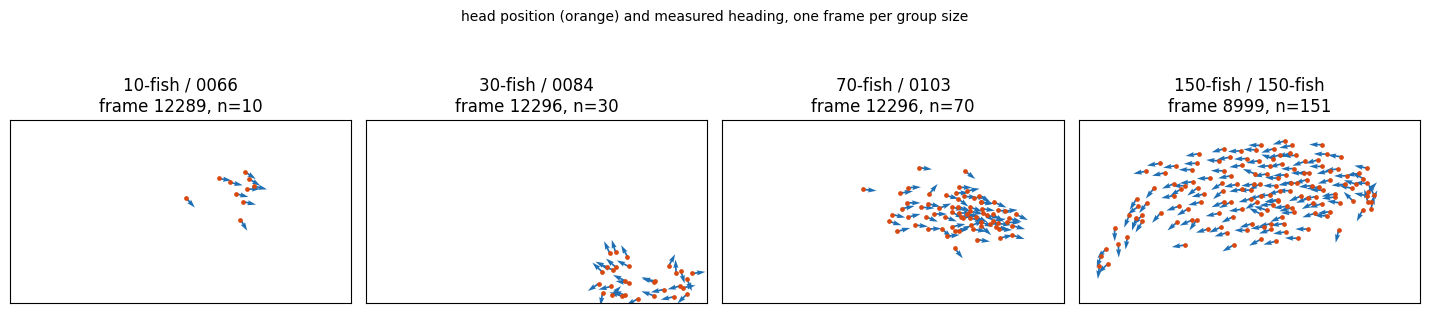

In [37]:
from scipy.optimize import linear_sum_assignment

entries = [(str(r["group"]), str(r["sequence"])) for _, r in index.iterrows()]
if TRIALS is not None:
    entries = [e for e in entries if e in TRIALS]

print(f"{'group':10s} {'sequence':10s} {'matched px':>12s} {'next best px':>13s} "
      f"{'margin':>7s}  ok")
for group, sequence in entries:
    segments = sorted((STAGED / group / sequence).glob("*_fov.h5"))
    if len(segments) < 2:
        print(f"{group:10s} {sequence:10s} {'one segment, no joins':>34s}")
        continue
    matched, runner_up = [], []
    for earlier, later in zip(segments[:-1], segments[1:]):
        with h5py.File(earlier, "r") as f:
            last = np.stack([f["fields/x"][:, -1], f["fields/y"][:, -1]], axis=-1)
        with h5py.File(later, "r") as f:
            first = np.stack([f["fields/x"][:, 0], f["fields/y"][:, 0]], axis=-1)
        cost = np.linalg.norm(first[:, None, :] - last[None, :, :], axis=-1)
        rows, cols = linear_sum_assignment(cost)
        matched.append(cost[rows, cols])
        runner_up.append(np.array([np.delete(cost[i], cols[i]).min() for i in rows]))
    matched = np.concatenate(matched)
    runner_up = np.concatenate(runner_up)
    margin = np.median(runner_up) / np.median(matched)
    ok = margin > 3.0
    print(f"{group:10s} {sequence:10s} {np.median(matched):5.2f}/{matched.max():5.2f} "
          f"{np.median(runner_up):6.2f}       {margin:>6.1f}x  {ok}")

fig, axes = plt.subplots(1, len(order_groups := [g for g in GROUPS if g in
                                                 {e[0] for e in entries}]),
                         figsize=(3.6 * len(order_groups), 3.9))
for ax, group in zip(np.atleast_1d(axes), order_groups):
    group_entry = next(e for e in entries if e[0] == group)
    tracks = ds.load_tracks(*group_entry)
    frame_no = int(tracks.frame.quantile(0.5, interpolation="nearest"))
    snapshot = tracks[tracks.frame == frame_no]
    ax.quiver(snapshot.X, snapshot.Y,
              np.cos(snapshot.ANGLE), np.sin(snapshot.ANGLE),
              angles="xy", scale=26, width=0.005, color="#1f6fb4")
    ax.plot(snapshot.X, snapshot.Y, "o", ms=2.4, color="#d9480f")
    ax.set_aspect("equal")
    ax.invert_yaxis()   # image coordinates: +Y points down
    ax.set(title=f"{group} / {group_entry[1]}\nframe {frame_no}, n={len(snapshot)}",
           xlim=(0, 1920), ylim=(1032, 0), xticks=[], yticks=[])
fig.suptitle("head position (orange) and measured heading, one frame per group size",
             fontsize=10)
fig.tight_layout()

## 6. Collective motion

Two order parameters, from Tunstrom et al. (2013). With `u_i` the unit heading of
individual `i` and `r_i` the unit vector from the group centroid to it:

- **polarization** `O_p = |mean(u_i)|` -- how aligned the group is, 0 to 1.
- **rotation** `O_r = |mean(u_i x r_i)|` -- how much it circles its own centre.

High polarization with low rotation is a **polarized** school; the reverse is a
**mill**; both low is a disordered **swarm**; anything else is **transitional**.

`heading_source="auto"` uses `ANGLE` where the table carries a usable one and
falls back to the direction of travel otherwise. Here it should resolve to
`orientation` for every entry -- and the output records which, so the choice is
auditable rather than assumed.

One caveat if you compare these numbers against the paper: its 0.35 / 0.65
thresholds were applied to a smoothed order-parameter series, and classifying
every raw frame puts noticeably more of them in `Transitional`. Per-frame
`O_p` and `O_r` have variance of order 1/N, which is large at ten fish. Smoothing
is a presentation choice about a series rather than part of the measurement, so
it is not done here; a `.rolling()` before plotting is all it takes.

In [40]:
from mosaic.behavior.feature_library.collective_motion_metrics import CollectiveMotionMetrics

result = ds.run_feature(
    CollectiveMotionMetrics(params={"fps": FPS}),
    entries=TRIALS,
)
print(result)

RESULTS_DIR = ds.get_root("features") / result.feature / result.run_id
check = pd.read_parquet(sorted(RESULTS_DIR.glob("*.parquet"))[0])
sources = check.heading_source.unique()
assert list(sources) == ["orientation"], f"expected measured headings, got {sources}"

print()
print("mosaic is done. Everything Part B needs is on disk:")
print(f"  tracks   {ds.get_root('tracks')}")
print(f"  results  {RESULTS_DIR}")
print(f"           {len(list(RESULTS_DIR.glob('*.parquet')))} parquet files, "
      f"one per entry")

[feature:collective-motion-metrics__from__tracks] completed run_id=0.1-147cf384d6 -> /Volumes/JD-SSD/CollectiveDetection_Shiners_Data/dataset/features/collective-motion-metrics__from__tracks/0.1-147cf384d6
Result(feature='collective-motion-metrics__from__tracks', run_id='0.1-147cf384d6', execution_id='01KZNZQJK2M0JET0GRBS2E21GC', cache_hit=True, failed_entries=())

mosaic is done. Everything Part B needs is on disk:
  tracks   /Volumes/JD-SSD/CollectiveDetection_Shiners_Data/dataset/tracks
  results  /Volumes/JD-SSD/CollectiveDetection_Shiners_Data/dataset/features/collective-motion-metrics__from__tracks/0.1-147cf384d6
           10 parquet files, one per entry


[feature:collective-motion-metrics] served 10 cached entry(ies) whose source cannot be checked: neither the run nor tracks records a composition for them, so a change under tracks would go unnoticed. Run `mosaic reindex` (or `mosaic reprobe-media --apply` for media) to write the projection.


---

# Part B -- load the results and plot

Nothing below calls mosaic. It reads the parquet Part A wrote and draws figures
with pandas and matplotlib, the same as any other analysis would.

The only thing carried across the boundary is a path. `RESULTS_DIR` is
`features/<feature>/<run_id>/`, where `run_id` identifies the exact parameters
and inputs that produced it -- so quoting that path in a paper names a
reproducible computation, not just a folder.

In [42]:
# Everything this half needs, so it stands on its own: RESULTS_DIR and these.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

results = pd.concat(
    [pd.read_parquet(p) for p in sorted(RESULTS_DIR.glob("*.parquet"))],
    ignore_index=True,
)

# Order the group sizes by the number of individuals actually in them, taken
# from the results rather than from a list written earlier.
order = results.groupby("group").n_ids.max().sort_values().index.tolist()

print(f"columns: {', '.join(results.columns)}")
results.groupby("group", sort=False)[["n_ids", "polarization", "rotation"]].mean().round(3)

columns: frame, time, n_ids, n_ids_heading, n_at_centroid, n_centroid_common, polarization, mean_heading, rotation, rotation_signed, group_angvel, state, centroid_x, centroid_y, centroid_speed, centroid_heading, sd_major, sd_minor, elongation, principal_axis_angle, area, density, heading_source, sequence, group


,n_ids,polarization,rotation
group,,,
10-fish,10.0,0.849,0.181
150-fish,151.0,0.590,0.362
30-fish,30.0,0.738,0.222
70-fish,70.0,0.552,0.331


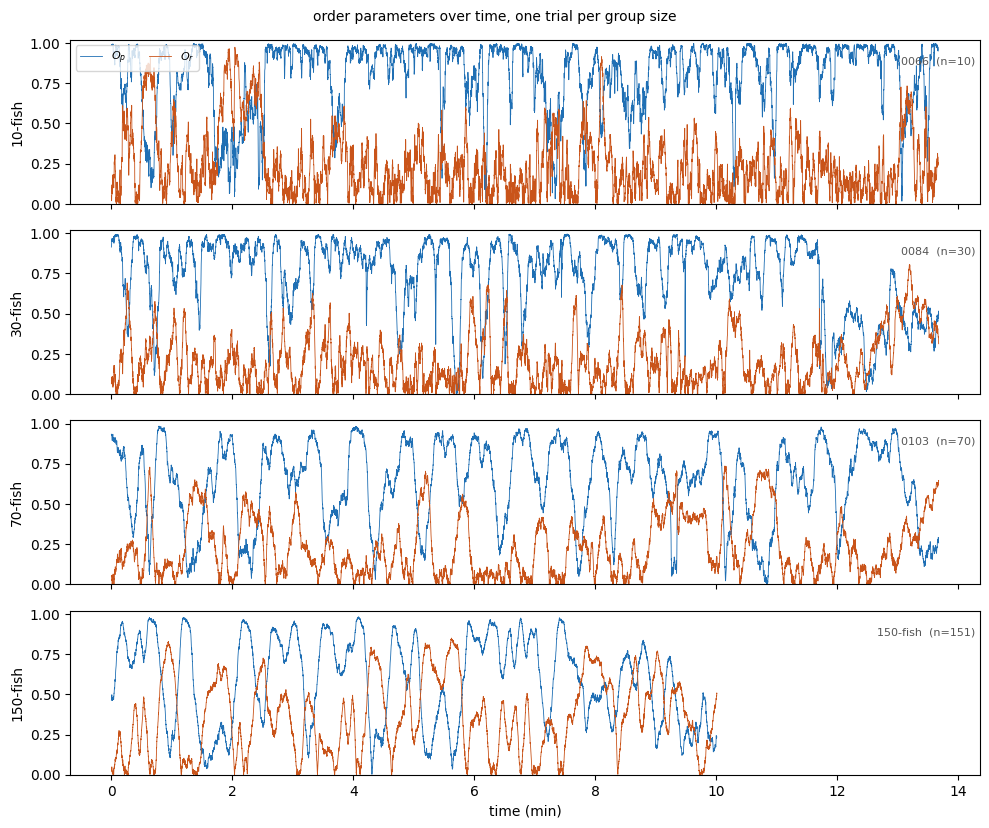

In [43]:
fig, axes = plt.subplots(len(order), 1, figsize=(10, 2.1 * len(order)), sharex=True)
for ax, group in zip(np.atleast_1d(axes), order):
    sub = results[results.group == group]
    first = sub.sequence.iloc[0]
    one = sub[sub.sequence == first].sort_values("time")
    ax.plot(one.time / 60, one.polarization, lw=0.6, color="#1f6fb4", label="$O_p$")
    ax.plot(one.time / 60, one.rotation, lw=0.6, color="#c9541a", label="$O_r$")
    ax.set(ylabel=group, ylim=(0, 1.02))
    ax.text(0.995, 0.9, f"{first}  (n={int(one.n_ids.max())})", ha="right", va="top",
            transform=ax.transAxes, fontsize=8, color="#555")
np.atleast_1d(axes)[0].legend(loc="upper left", ncols=2, fontsize=8)
np.atleast_1d(axes)[-1].set_xlabel("time (min)")
fig.suptitle("order parameters over time, one trial per group size", fontsize=10)
fig.tight_layout()

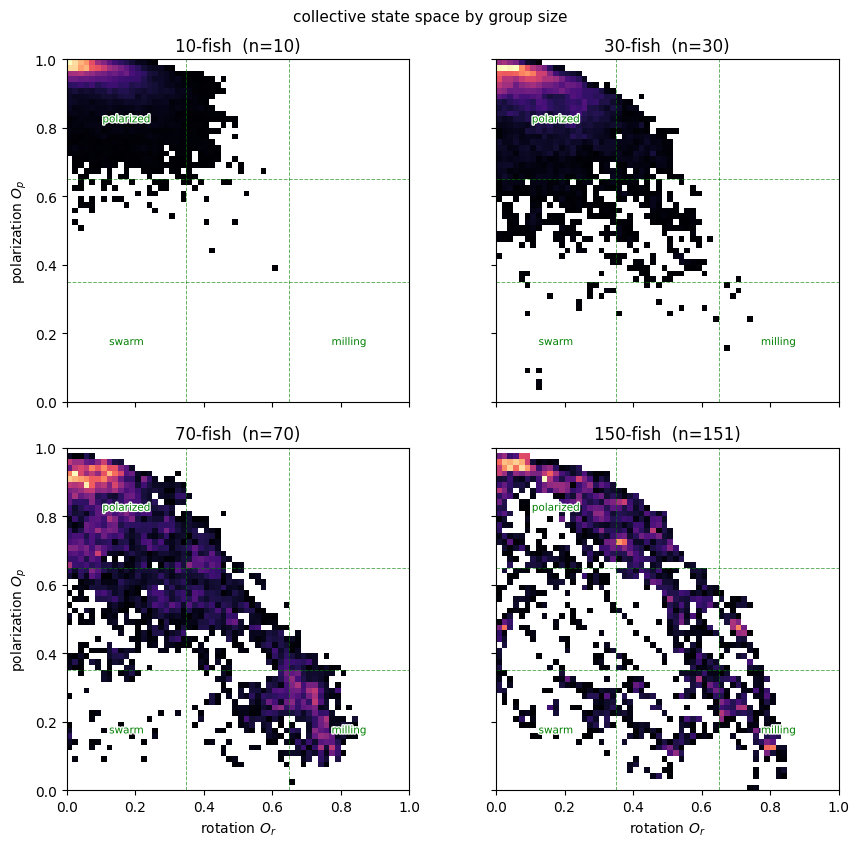

In [51]:
import matplotlib.patheffects as pe

STATE_HIGH, STATE_LOW = (0.65, 0.35)  # thresholds that define each discrete state

# Where each state sits, derived from the thresholds so the labels follow if
# those change. The classifier reads:
#   |O_r| < 0.35 and O_p < 0.35 -> swarm      |O_r| < 0.35 and O_p > 0.65 -> polarized
#   |O_r| > 0.65 and O_p < 0.35 -> milling    anything else               -> transitional
STATE_LABELS = [
    (STATE_LOW / 2, (1 + STATE_HIGH) / 2, "polarized"),
    (STATE_LOW / 2, STATE_LOW / 2, "swarm"),
    ((1 + STATE_HIGH) / 2, STATE_LOW / 2, "milling"),
]

n = len(order)
cols = 2 if n > 1 else 1
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(4.6 * cols, 4.3 * rows),
                         squeeze=False, sharex=True, sharey=True)
for ax, group in zip(axes.ravel(), order):
    sub = results[results.group == group].dropna(subset=["rotation", "polarization"])
    h = ax.hist2d(sub.rotation, sub.polarization, bins=60, range=[[0, 1], [0, 1]],
                  cmap="magma", cmin=1, density=True)
    for level in (STATE_LOW, STATE_HIGH):
        ax.axhline(level, color="g", lw=0.7, ls="--", alpha=0.6)
        ax.axvline(level, color="g", lw=0.7, ls="--", alpha=0.6)
    for tx, ty, label in STATE_LABELS:
        ax.text(tx, ty, label, color="g", fontsize=7.5, ha="center", va="center",
                path_effects=[pe.withStroke(linewidth=2.0, foreground="white")])
    ax.set(title=f"{group}  (n={int(sub.n_ids.max())})", aspect="equal")
for ax in axes.ravel()[n:]:
    ax.axis("off")
for ax in axes[-1]:
    ax.set_xlabel("rotation $O_r$")
for ax in axes[:, 0]:
    ax.set_ylabel("polarization $O_p$")
fig.suptitle("collective state space by group size", fontsize=11)
fig.tight_layout()


state,Polarized,Milling,Swarm,Transitional,Undefined
group,,,,,
10-fish,80.0,0.8,1.1,18.1,0.0
30-fish,64.1,1.7,3.8,30.4,0.0
70-fish,36.5,13.1,5.3,45.1,0.0
150-fish,36.2,10.2,5.9,47.8,0.0


tick marks are individual trials; 10/30/70-fish have three each, 150-fish one


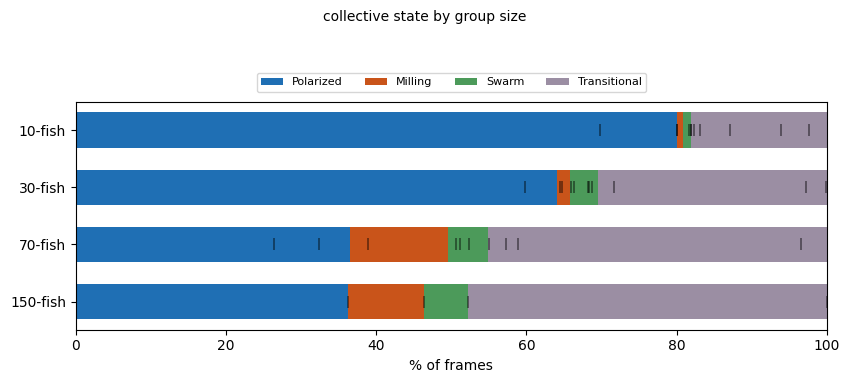

In [52]:
STATES = ["Polarized", "Milling", "Swarm", "Transitional", "Undefined"]
COLORS = {"Polarized": "#1f6fb4", "Milling": "#c9541a", "Swarm": "#4c9a5a",
          "Transitional": "#9b8ea3", "Undefined": "#cccccc"}

by_group = (
    results.groupby("group").state.value_counts(normalize=True).unstack(fill_value=0) * 100
).reindex(index=order).reindex(columns=STATES).fillna(0.0)
by_trial = (
    results.groupby(["group", "sequence"]).state.value_counts(normalize=True)
    .unstack(fill_value=0) * 100
).reindex(columns=STATES).fillna(0.0)

present = [s for s in STATES if by_group[s].sum() > 0.01]
fig, ax = plt.subplots(figsize=(8.6, 3.6))
left = np.zeros(len(order))
y = np.arange(len(order))
for state in present:
    ax.barh(y, by_group[state], left=left, color=COLORS[state], label=state, height=0.62)
    # per-trial points, so the unequal number of trials per group stays visible
    for i, group in enumerate(order):
        pts = by_trial.loc[group, state]
        ax.plot(left[i] + np.atleast_1d(pts), np.full(np.size(pts), y[i]), "|",
                color="k", ms=9, mew=1.1, alpha=0.55)
    left += by_group[state].to_numpy()
ax.set(yticks=y, yticklabels=order, xlabel="% of frames", xlim=(0, 100))
ax.invert_yaxis()
ax.legend(ncols=len(present), fontsize=8, loc="lower center", bbox_to_anchor=(0.5, 1.02))
fig.suptitle("collective state by group size", y=1.05, fontsize=10)
fig.tight_layout()

display(by_group.round(1))
print("tick marks are individual trials; 10/30/70-fish have three each, 150-fish one")

## 7. Using this for your own data

Cells 2, 4 and the converter are format-specific. Everything from section 4
onwards is not -- it runs on any schema-valid track table, whatever produced it.

To adapt the converter, answer three questions:

1. **Does one file hold many sequences, or do many files make one sequence?**
   Set `enumerable = True` and implement `enumerate_sequences`, or
   `merges_per_sequence = True` and override `sequence_from_stem`. They are
   mutually exclusive. If files are several per sequence, check whether identity
   and frame numbering survive the joins -- here neither did, and both had to be
   repaired.
2. **Does your tracker measure anything `mosaic_v1` forbids?** If it genuinely
   reports a heading or a speed, declare a schema that `extends="mosaic_v1"` and
   `allows` exactly that column. If it does not, emit `mosaic_v1` and let a
   feature derive it -- that is the honest answer, and the one that records how
   the derivation was done.
3. **Are your coordinates already video pixels?** `mosaic_v1` says they are. If
   yours are physical units or re-centred, convert in the converter and say so in
   its docstring, or the numbers will be wrong by a factor nobody recorded.

[Adding a converter](../docs/adding-a-converter.md) covers the full contract,
including how to ship a converter inside mosaic rather than in a notebook, and
what the registry tests then check for you.